In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
dados = pd.read_csv('dados.txt',sep='\t')

a = 265.025880
b = 0.033187
c = 17.890934

Função ajustada:
y = 17.890934 + 265.025880 * exp(-0.033187 * x)
R² = 0.993592


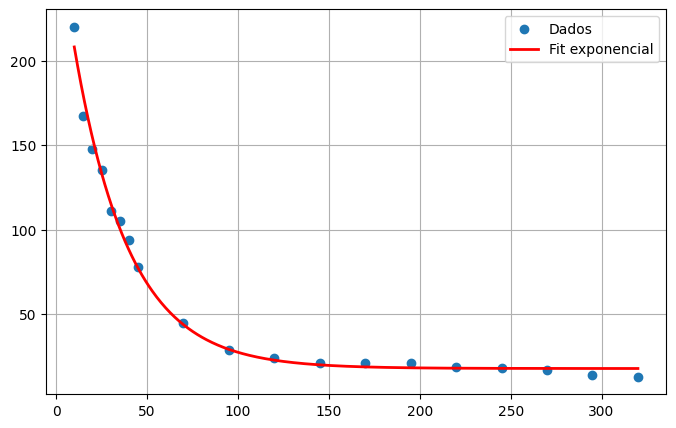

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = dados['Altura'].to_numpy()
y = dados['Foco'].to_numpy()

# Modelo exponencial
def expo(x, a, b, c):
    return c + a*np.exp(-b*x)

# Chute inicial
p0 = [y.max()-y.min(), 0.03, y.min()]

params, cov = curve_fit(expo, x, y, p0=p0)

a, b, c = params

# Imprime parâmetros
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"c = {c:.6f}")

# Imprime a equação
print("\nFunção ajustada:")
print(f"y = {c:.6f} + {a:.6f} * exp(-{b:.6f} * x)")

# R²
y_pred = expo(x, *params)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

print(f"R² = {r2:.6f}")

# Plot
xx = np.linspace(x.min(), x.max(), 500)

plt.figure(figsize=(8,5))
plt.scatter(x, y, label='Dados')
plt.plot(xx, expo(xx, *params), 'r', lw=2, label='Fit exponencial')
plt.grid(True)
plt.legend()
plt.show()